In [39]:
import pandas as pd
df = pd.read_csv('/content/house_prices.csv.zip')
df.head()

,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,...,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,...,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,...,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,...,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,...,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN


In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              187531 non-null  int64  
 1   Title              187531 non-null  object 
 2   Description        184508 non-null  object 
 3   Amount(in rupees)  187531 non-null  object 
 4   Price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  object 
 6   Carpet Area        106858 non-null  object 
 7   Status             186916 non-null  object 
 8   Floor              180454 non-null  object 
 9   Transaction        187448 non-null  object 
 10  Furnishing         184634 non-null  object 
 11  facing             117298 non-null  object 
 12  overlooking        106095 non-null  object 
 13  Society            77853 non-null   object 
 14  Bathroom           186703 non-null  object 
 15  Balcony            138596 non-null  object 
 16  Ca

In [41]:
df.isnull().sum()

,0
Index,0
Title,0
Description,3023
Amount(in rupees),0
Price (in rupees),17665
location,0
Carpet Area,80673
Status,615
Floor,7077
Transaction,83


In [42]:
df = df[[
    "Price (in rupees)",
    "Carpet Area",
    "location",
    "Furnishing",
    "Bathroom",
    "Balcony"
]]
df.head()

,Price (in rupees),Carpet Area,location,Furnishing,Bathroom,Balcony
0,6000.0,500 sqft,thane,Unfurnished,1,2
1,13799.0,473 sqft,thane,Semi-Furnished,2,NaN
2,17500.0,779 sqft,thane,Unfurnished,2,NaN
3,NaN,530 sqft,thane,Unfurnished,1,1
4,18824.0,635 sqft,thane,Unfurnished,2,NaN


In [43]:
x = df.drop("Price (in rupees)", axis=1)
y = df["Price (in rupees)"]

In [26]:
x=pd.get_dummies(x, drop_first = True)


In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [28]:
X = df.drop("Price (in rupees)", axis=1)
y = df["Price (in rupees)"]

In [29]:
from sklearn.linear_model import LinearRegression

# Create a boolean mask to identify rows where y_train is NOT NaN
not_nan_mask = ~y_train.isna()

# Filter X_train and y_train using the mask
X_train_cleaned = X_train[not_nan_mask]
y_train_cleaned = y_train[not_nan_mask]

model = LinearRegression()

# Fit the model with the cleaned data
model.fit(X_train_cleaned, y_train_cleaned)

LinearRegression()

In [30]:
predictions = model.predict(X_test)
print(predictions[::10])

[ 9385.89427159 14635.01028158 12854.         ...  7835.92455492
 13011.07402238  8865.93795809]


In [31]:
from sklearn.metrics import r2_score

# Create a boolean mask to identify rows where y_test is not NaN
not_nan_mask_test = ~y_test.isna()

# Filter y_test and predictions using the mask
y_test_cleaned = y_test[not_nan_mask_test]
predictions_cleaned = predictions[not_nan_mask_test]

score = r2_score(y_test_cleaned, predictions_cleaned)
print(f"model accuracy: {score}")

model accuracy: -0.27636361179277125


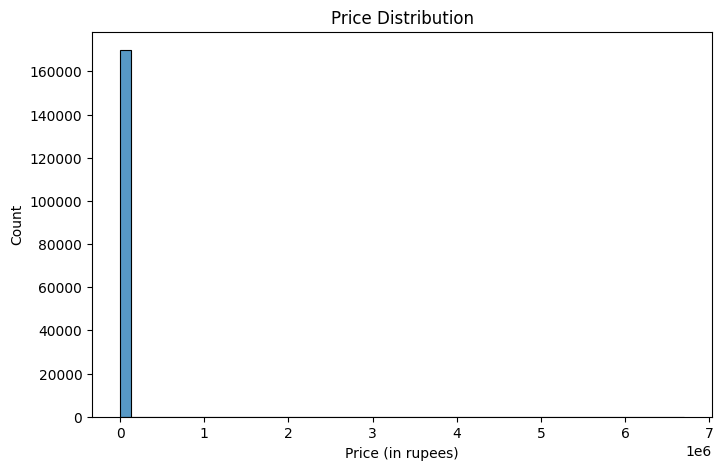

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,5))
sns.histplot(df["Price (in rupees)"], bins=50)
plt.title("Price Distribution")
plt.show()

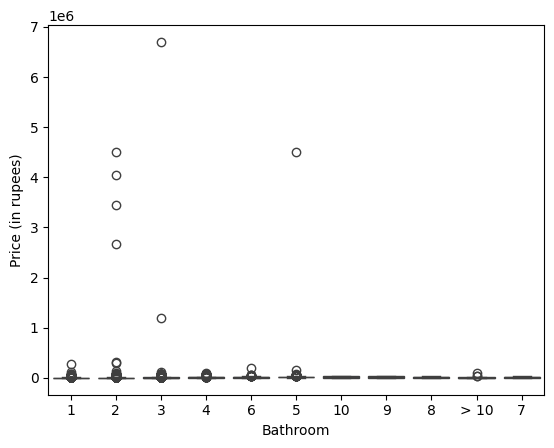

In [33]:
sns.boxplot(x="Bathroom", y="Price (in rupees)", data=df)
plt.show()

In [34]:
from sklearn.linear_model import LinearRegression

# remove NaN rows
not_nan_mask = ~y_train.isna()

X_train_cleaned = X_train[not_nan_mask]
y_train_cleaned = y_train[not_nan_mask]

model = LinearRegression()

model.fit(X_train_cleaned, y_train_cleaned)

LinearRegression()

In [35]:
not_nan_mask_test = ~y_test.isna()

X_test_cleaned = X_test[not_nan_mask_test]
y_test_cleaned = y_test[not_nan_mask_test]

predictions = model.predict(X_test_cleaned)

In [36]:
from sklearn.metrics import r2_score

score = r2_score(y_test_cleaned, predictions)

print("Model Accuracy:", score)

Model Accuracy: -0.27636361179277125


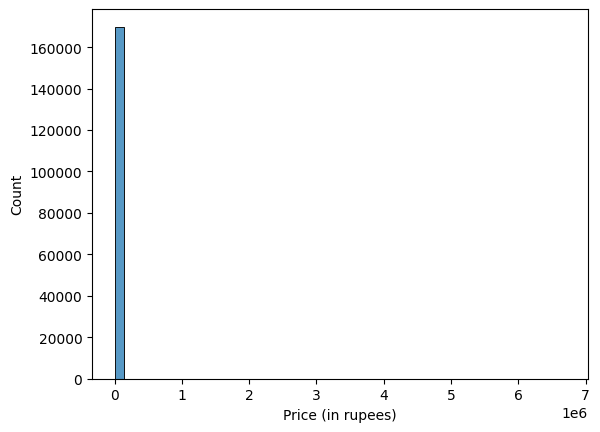

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df["Price (in rupees)"], bins=50)
plt.show()

<>:8: SyntaxWarning: invalid escape sequence '\d'
<>:8: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_26706/638630771.py:8: SyntaxWarning: invalid escape sequence '\d'
  df_numeric['Carpet Area'] = df_numeric['Carpet Area'].str.extract('(\d+)').astype(float)


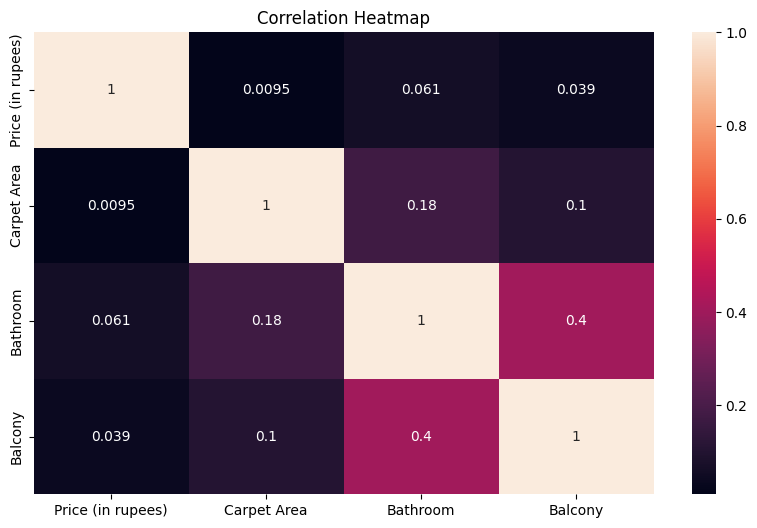

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a copy of the dataframe to avoid modifying the original 'df' in case it's needed elsewhere
df_numeric = df.copy()

# Clean 'Carpet Area' column
df_numeric['Carpet Area'] = df_numeric['Carpet Area'].str.extract('(\d+)').astype(float)

# Clean 'Bathroom' and 'Balcony' columns (if they are not already numeric)
df_numeric['Bathroom'] = pd.to_numeric(df_numeric['Bathroom'], errors='coerce')
df_numeric['Balcony'] = pd.to_numeric(df_numeric['Balcony'], errors='coerce')

plt.figure(figsize=(10,6))
sns.heatmap(df_numeric.corr(numeric_only=True), annot=True)
plt.title('Correlation Heatmap')
plt.show()